# 🔹 STEP 1: Import Required Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")  # nicer plots


# 🔹 STEP 2: Load the Dataset

In [10]:
df = pd.read_csv('SuperMarket Analysis.csv')


# 🔹 STEP 3: Understand the Data

In [18]:
# View first 5 rows
df.head()


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day,Year
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,1,5,2019
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,3,8,2019
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,3,3,2019
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,1,27,2019
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,2,8,2019


In [19]:
# Structure & data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [20]:
# Statistical summary
df.describe()


,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Rating,Month,Day,Year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.0
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905,15.379369,6.97270,1.993000,15.256000,2019.0
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905,0.508500,4.00000,1.000000,1.000000,2019.0
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905,5.924875,5.50000,1.000000,8.000000,2019.0
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905,12.088000,7.00000,2.000000,15.000000,2019.0
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905,22.445250,8.50000,3.000000,23.000000,2019.0
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905,49.650000,10.00000,3.000000,31.000000,2019.0
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,0.000000,11.708825,1.71858,0.835254,8.693563,0.0


# 🔹 STEP 4: Check Data Quality

In [21]:
# Missing values
df.isnull().sum()


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Day                        0
Year                       0
dtype: int64

In [22]:
# Duplicate rows
df.duplicated().sum()


np.int64(0)

In [23]:
# Remove duplicates if any
df = df.drop_duplicates()


# 🔹 STEP 5: Data Cleaning & Feature Engineering

Convert Date Column

In [24]:
df['Date'] = pd.to_datetime(df['Date'])


Extract useful time features

In [25]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year


# 🔹 STEP 6: Exploratory Data Analysis (EDA)

1: Total Sales by Branch

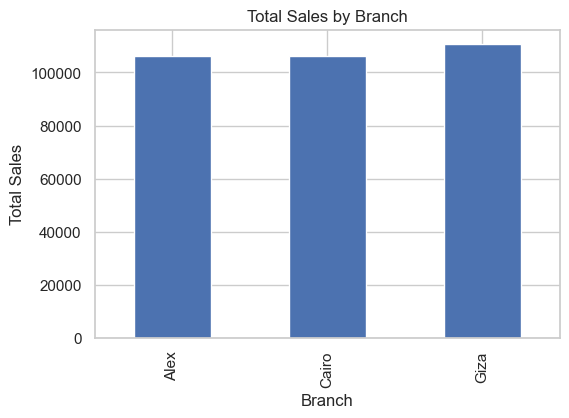

In [27]:
branch_sales = df.groupby('Branch')['Sales'].sum()

plt.figure(figsize=(6,4))
branch_sales.plot(kind='bar')
plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")
plt.show()


2: Monthly Sales Trend

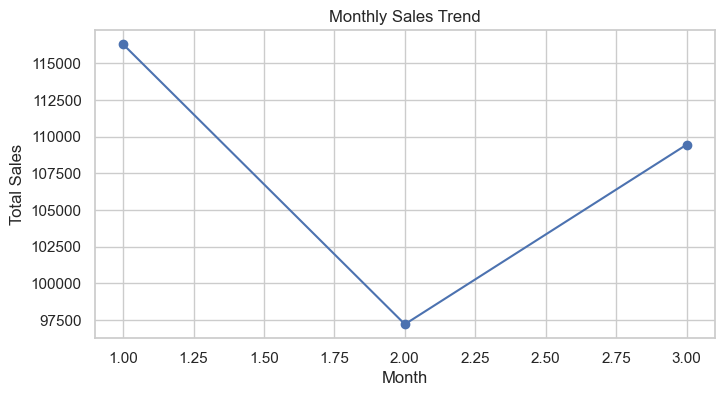

In [31]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(8,4))
plt.plot(monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


3: Total Sales by Product Line

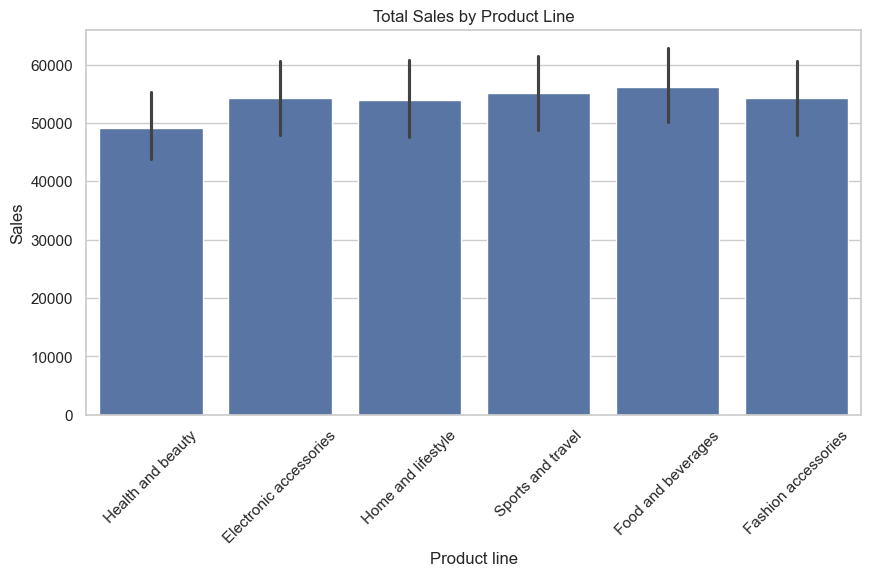

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='Product line',
    y='Sales',
    data=df,
    estimator=sum
)
plt.xticks(rotation=45)
plt.title("Total Sales by Product Line")
plt.show()


4: Sales by Customer Type

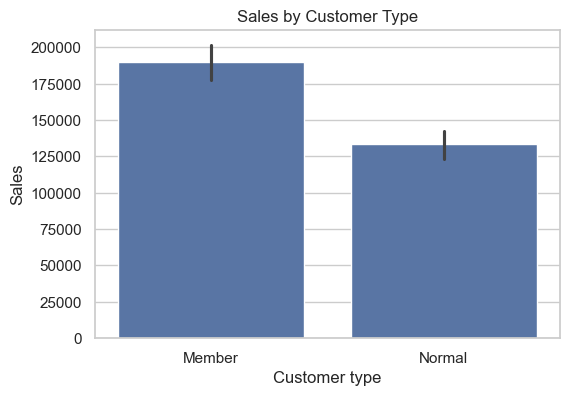

In [34]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='Customer type',
    y='Sales',
    data=df,
    estimator=sum
)
plt.title("Sales by Customer Type")
plt.show()


5: Sales by Gender

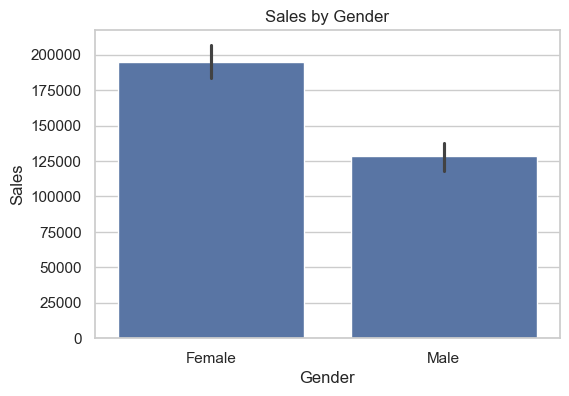

In [35]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='Gender',
    y='Sales',
    data=df,
    estimator=sum
)
plt.title("Sales by Gender")
plt.show()


6: Payment Method Distribution

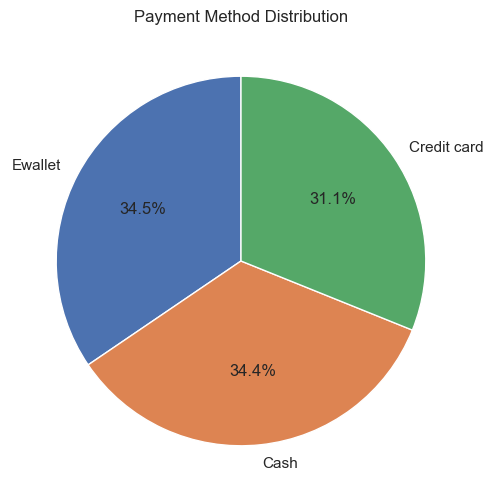

In [36]:
plt.figure(figsize=(6,6))
df['Payment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


7: Average Rating by Branch

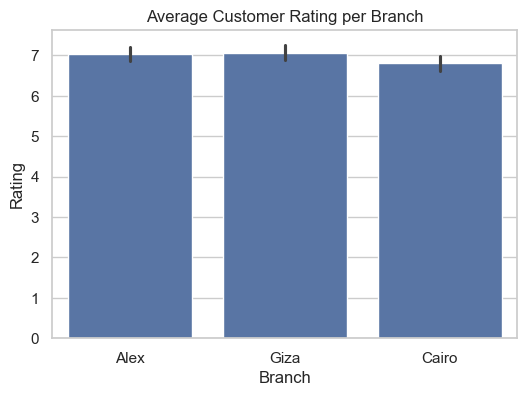

In [37]:
plt.figure(figsize=(6,4))
sns.barplot(
    x='Branch',
    y='Rating',
    data=df
)
plt.title("Average Customer Rating per Branch")
plt.show()


# 🔹 STEP 7: Business Insights

In [38]:
print("KEY INSIGHTS:")
print("1. One branch generates higher total sales than others.")
print("2. Certain product lines contribute most to revenue.")
print("3. Members spend more than normal customers.")
print("4. Cash is the most frequently used payment method.")
print("5. Monthly sales show variation, useful for planning inventory.")


KEY INSIGHTS:
1. One branch generates higher total sales than others.
2. Certain product lines contribute most to revenue.
3. Members spend more than normal customers.
4. Cash is the most frequently used payment method.
5. Monthly sales show variation, useful for planning inventory.


# 🔹 STEP 8: Save Cleaned Data

In [39]:
df.to_csv("Supermarket_Sales_Cleaned.csv", index=False)
